### NBA MVP Prediction Model Comparison

Logistic Regression, Random Forest, XGBoost, and LightGBM models

In [1]:
# Imports

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

In [2]:
# Load the dataset

train = pd.read_csv("Data/train.csv")
valid = pd.read_csv("Data/valid.csv")
test = pd.read_csv("Data/test.csv")

print("Train:", train.shape)
print("Validation:", valid.shape)
print("Test:", test.shape)

Train: (14679, 34)
Validation: (3196, 34)
Test: (4399, 34)


In [74]:
# Choose features
TARGET = "Rk"

DROP_COLUMNS = [
    "Player",
    "Season",
    "Rk"
]

FEATURES = ["Age", "G", "MP", "PTS", "TRB", "AST", "STL", "BLK", "FG%", "3P%", "FT%", "TOV"]

X_train = train[FEATURES]
y_train = train[TARGET]

X_valid = valid[FEATURES]
y_valid = valid[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print(len(FEATURES), "features")

12 features


In [75]:
# Le models

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=600, class_weight="balanced", random_state=2),
    "XGBoost": XGBClassifier(n_estimators=600, max_depth=11, learning_rate=0.01, scale_pos_weight=450, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, class_weight="balanced",random_state=42)
}

In [76]:
# Training functions

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

NaN Handle

In [77]:
print(X_train.isna().sum().sort_values(ascending=False))

3P%    2708
FT%     600
FG%      76
Age       0
G         0
MP        0
PTS       0
TRB       0
AST       0
STL       0
BLK       0
TOV       0
dtype: int64


In [78]:
# NaN usually means "no attempts"
percentage_cols = ["FG%", "3P%", "2P%", "FT%", "eFG%"]

for col in percentage_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0)
        X_valid[col] = X_valid[col].fillna(0)
        X_test[col] = X_test[col].fillna(0)

# median everything else
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_valid = pd.DataFrame(imputer.transform(X_valid), columns=X_valid.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

/var/folders/k6/8jpj0vw52xv085bb0gshjnfw0000gn/T/ipykernel_55472/1792360125.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].fillna(0)
/var/folders/k6/8jpj0vw52xv085bb0gshjnfw0000gn/T/ipykernel_55472/1792360125.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid[col] = X_valid[col].fillna(0)
/var/folders/k6/8jpj0vw52xv085bb0gshjnfw0000gn/T/ipykernel_55472/1792360125.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [79]:
# Train all the models

results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    results.append(evaluate_model(name, model))

results = pd.DataFrame(results)

results

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 14651, number of negative: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1755
[LightGBM] [Info] Number of data points in the train set: 14679, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.963173,1.000000,0.963123,0.981215
1,Random Forest,0.998636,0.998636,1.000000,0.999318
2,XGBoost,0.998636,0.998636,1.000000,0.999318
3,LightGBM,0.999545,1.000000,0.999545,0.999772


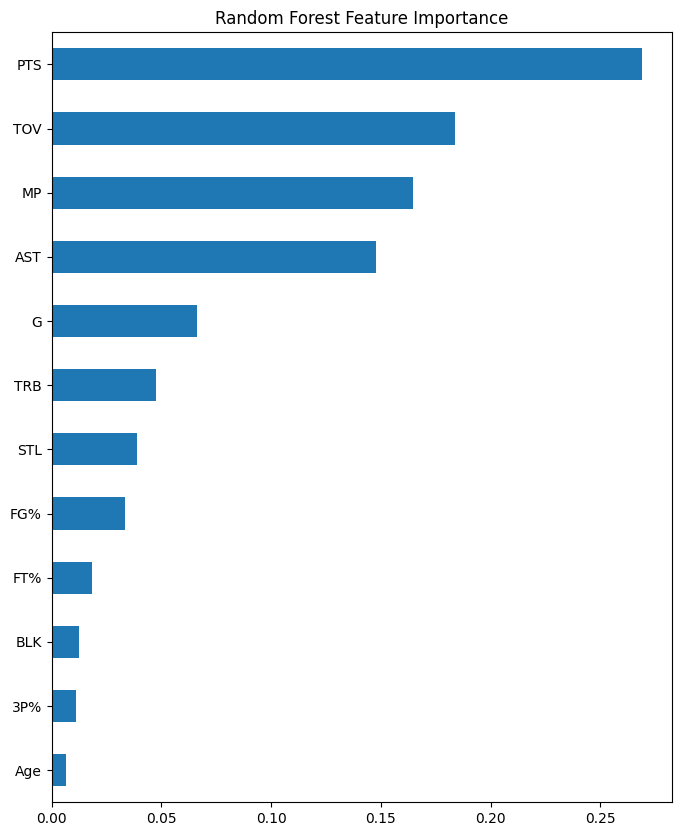

In [ ]:
# Feature importance

importance_df = pd.DataFrame({
    "Random Forest": trained_models["Random Forest"].feature_importances_,
    "XGBoost": trained_models["XGBoost"].feature_importances_,
    "LightGBM": trained_models["LightGBM"].feature_importances_,
    "Logistic Regression": np.abs(trained_models["Logistic Regression"].coef_[0]),
}, index=FEATURES)

importance_df = importance_df.sort_index()

plt.figure(figsize=(12, 7))
importance_df.plot(kind="bar", figsize=(12, 7))
plt.title("Feature Importance Comparison")
plt.ylabel("Importance / Coefficient magnitude")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

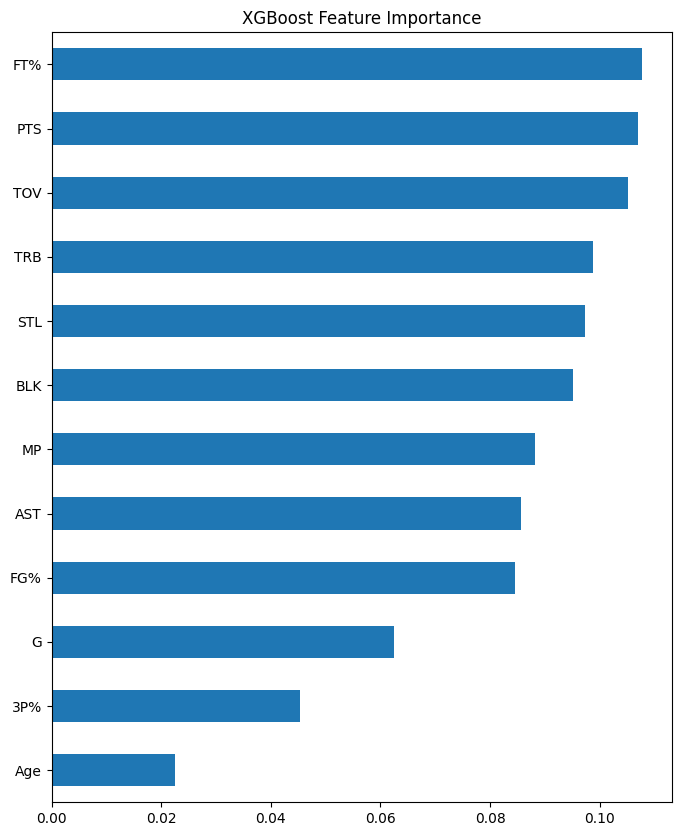

In [82]:
# XGBoost feature importance

xgb = trained_models["XGBoost"]

importance = pd.Series(
    xgb.feature_importances_,
    index=FEATURES
)

importance = importance.sort_values()

plt.figure(figsize=(8,10))
importance.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.show()

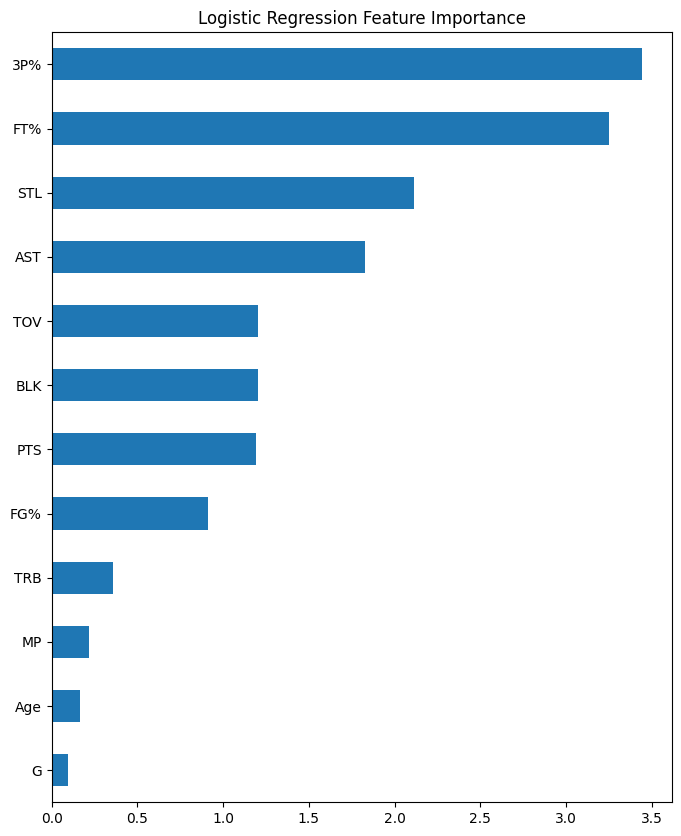

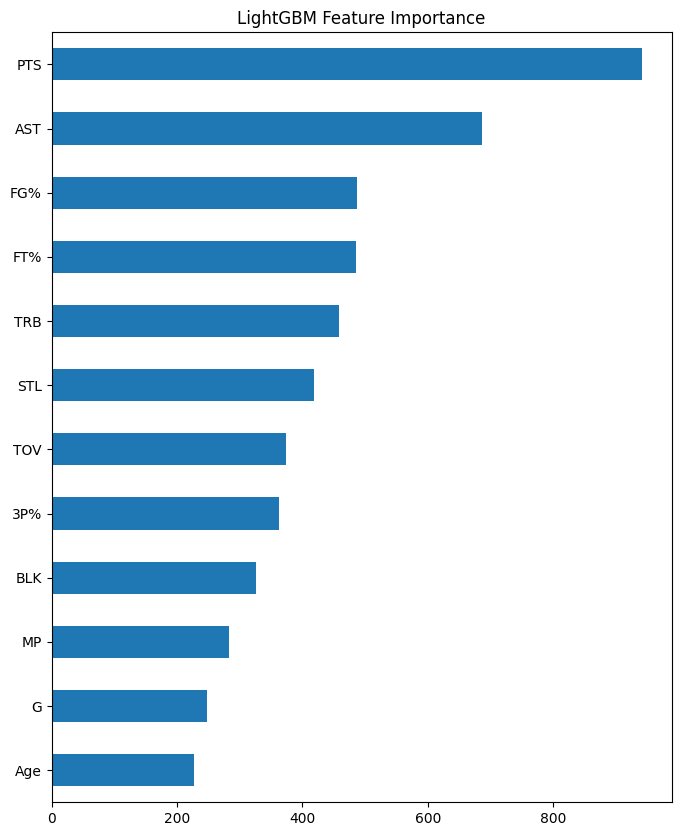

In [83]:
# Logistic Regression feature importance

lr = trained_models["Logistic Regression"]

importance = pd.Series(
    np.abs(lr.coef_[0]),
    index=FEATURES
)

importance = importance.sort_values()

plt.figure(figsize=(8,10))
importance.plot(kind="barh")
plt.title("Logistic Regression Feature Importance")
plt.show()

# LightGBM feature importance

lgbm = trained_models["LightGBM"]

importance = pd.Series(
    lgbm.feature_importances_,
    index=FEATURES
)

importance = importance.sort_values()

plt.figure(figsize=(8,10))
importance.plot(kind="barh")
plt.title("LightGBM Feature Importance")
plt.show()

In [71]:
# Predict

best_model = trained_models["XGBoost"]

test_copy = test.copy()

test_copy["Probability"] = best_model.predict_proba(X_test)[:,0]

In [73]:
# Predict top 5 MVP candidates for each model and season

test_copy = test.copy()

for name, model in trained_models.items():
    proba = model.predict_proba(X_test)
    pos_class_idx = list(model.classes_).index(0)
    test_copy[f"{name} Probability"] = proba[:, pos_class_idx]

for season in sorted(test_copy["season"].unique()):
    print(f"\nSeason {season}")
    for name in trained_models:
        print(f"\n{name} top 5 MVP predictions")
        display(
            test_copy[test_copy["season"] == season]
            .sort_values(f"{name} Probability", ascending=False)
            [["Player", "Rk", f"{name} Probability"]]
            .head(5)
        )


Season 20-21

Logistic Regression top 5 MVP predictions


,Player,Rk,Logistic Regression Probability
0,Stephen Curry,1,0.999990
10,Nikola Jokić,0,0.999985
2,Damian Lillard,1,0.999983
20,James Harden,1,0.999924
5,Luka Dončić,1,0.999924



Random Forest top 5 MVP predictions


,Player,Rk,Random Forest Probability
10,Nikola Jokić,0,0.090000
24,Julius Randle,1,0.036667
0,Stephen Curry,1,0.031667
2,Damian Lillard,1,0.031667
13,Devin Booker,1,0.028333



XGBoost top 5 MVP predictions


...

,Player,Rk,Random Forest Probability
3673,Nikola Jokić,1,0.076667
3680,Kevin Durant,1,0.065000
3681,Jamal Murray,1,0.060000
3670,Tyrese Maxey,1,0.053333
3666,Luka Dončić,1,0.046667



XGBoost top 5 MVP predictions


,Player,Rk,XGBoost Probability
3673,Nikola Jokić,1,0.009176
3667,Shai Gilgeous-Alexander,0,0.006623
3674,Giannis Antetokounmpo,1,0.004699
3670,Tyrese Maxey,1,0.001724
3666,Luka Dončić,1,0.001534



LightGBM top 5 MVP predictions


,Player,Rk,LightGBM Probability
3667,Shai Gilgeous-Alexander,0,0.999219
3673,Nikola Jokić,1,0.756101
3681,Jamal Murray,1,0.017259
3674,Giannis Antetokounmpo,1,0.001698
3687,James Harden,1,0.001084
